## Bagging
Bagging (Bootstrap Aggregating) is a machine learning technique that improves model stability and accuracy by training multiple base models on random data subsets (with replacement) and combining their predictions, reducing variance and overfitting, commonly used with decision trees to create powerful ensembles like Random Forests. In other contexts, "bagging" can refer to agricultural fruit protection, slang for verbal teasing, or cycling challenges. 

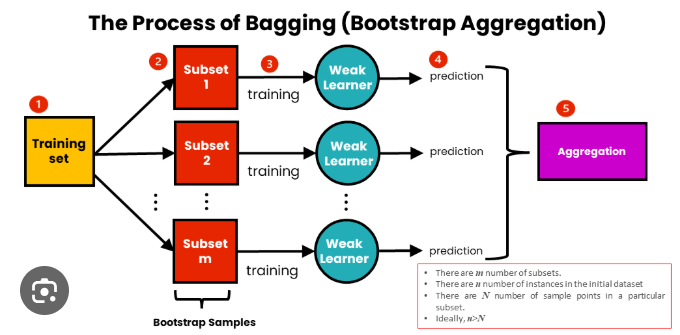

## In Machine Learning (Bootstrap Aggregating)
## Concept:
Trains many weak models (like decision trees) on different random samples of your data and averages their outputs (regression) or takes a majority vote (classification) for a better final prediction.
## Process:
## Bootstrapping:
Create multiple datasets by sampling from the original data with replacement.
## Parallel Training:
Train a model on each bootstrap sample independently.
## Aggregation:
Combine the predictions (average/vote) for the final result.
## Benefits:
Reduces variance, prevents overfitting, and boosts accuracy, especially for unstable models like decision trees.
## Types of Bagging
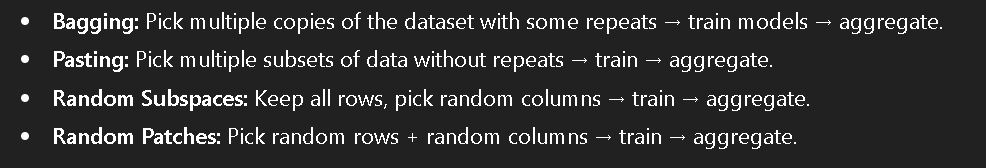

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [4]:
data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## # Bagging with replacement (default) 

In [6]:
# Bagging with replacement (default)
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=10,
    bootstrap=True,   # with replacement
    random_state=42
)
bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)
print("Bagging Accuracy:", accuracy_score(y_test, y_pred))


Bagging Accuracy: 1.0


## Pasting (no replacement)

In [7]:
pasting = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=10,
    bootstrap=False,  # without replacement
    random_state=42
)
pasting.fit(X_train, y_train)
y_pred = pasting.predict(X_test)
print("Pasting Accuracy:", accuracy_score(y_test, y_pred))

Pasting Accuracy: 1.0


## Random Subspace: sample features instead of samples

In [8]:
subspace = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=10,
    max_features=2,  # number of features to sample for each estimator
    bootstrap_features=True,
    random_state=42
)
subspace.fit(X_train, y_train)
y_pred = subspace.predict(X_test)
print("Random Subspace Accuracy:", accuracy_score(y_test, y_pred))

Random Subspace Accuracy: 0.9555555555555556


## Random Patches: sample both rows and features

In [10]:
patches = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=10,
    max_samples=0.7,      # 70% of samples
    max_features=0.7,     # 70% of features
    bootstrap=True,       # sample rows with replacement
    bootstrap_features=True,  # sample columns with replacement
    random_state=42
)
patches.fit(X_train, y_train)
y_pred = patches.predict(X_test)
print("Random Patches Accuracy:", accuracy_score(y_test, y_pred))

Random Patches Accuracy: 0.9555555555555556
